# Лучшая модель (вне учета бейзлайна) - Лог рег с оптуной
Лог рег показал себя чуть хуже

Берт тоже показал себя хуже

FastText, Word2vec (и скип грам и cbow) тоже показали себя хуже в связках с разными моделями  

TF IDF лучше всех с SVM

На втором месте лог рег с оптуной

Загрузка датасета...

=== ОБУЧЕНИЕ BASELINE (LogReg | C=4.22 | Weights=balanced) ===

ФИНАЛЬНЫЙ Score на тесте (100% данных): 0.8300
Detail: Queue MacroF1=0.8544, Priority Acc=0.6618, Type Acc=0.8844

=== ТОП-5 УВЕРЕННЫХ ОШИБОК (QUEUE) ===
                                                 subject              queue  \
3573                    Issue with SaaS Platform Service    Product Support   
17235               Assistance with Service Interruption    Product Support   
18335  Significant Service Interruption Impacting Dig...  Technical Support   
16217  Inquiry About Data Analytics Solutions for Inv...    Product Support   
61750  Inquiry About Data Analytics Solutions for Inv...    Product Support   

                            queue_pred  queue_conf  
3573   Service Outages and Maintenance    0.885219  
17235  Service Outages and Maintenance    0.864187  
18335  Service Outages and Maintenance    0.818553  
16217              Sales and Pre-Sales    0.777390  
61750              S

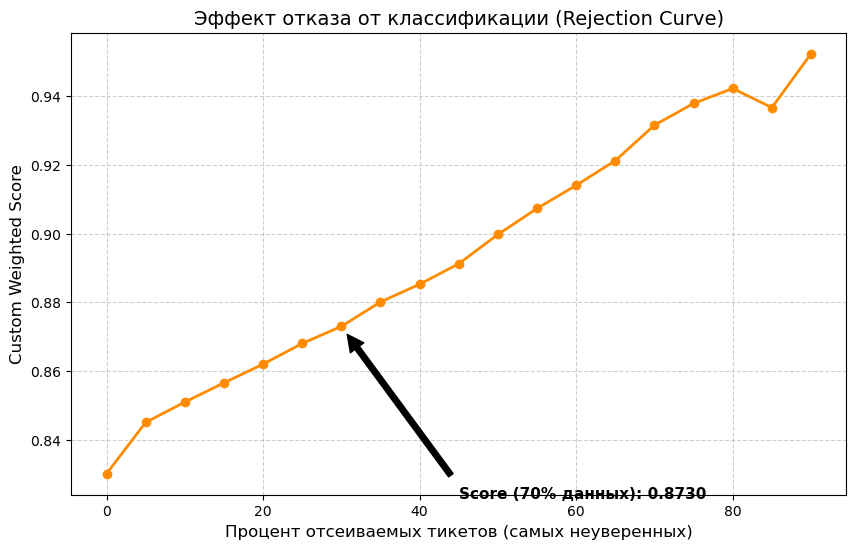


ГЛУБОКИЙ АНАЛИЗ ОШИБОК

>>> Анализ цели: QUEUE
Топ-3 класса, которые модель чаще всего не узнает:
  - Technical Support: 755 ошибок из 1418 (53.2%)
  - Product Support: 560 ошибок из 937 (59.8%)
  - Customer Service: 448 ошибок из 766 (58.5%)

Самые частые путаницы (Реальность -> Предсказание):
  - Technical Support ПУТАЕТ С IT Support: 195 раз
  - Technical Support ПУТАЕТ С Product Support: 171 раз
  - Product Support ПУТАЕТ С Technical Support: 168 раз

>>> Анализ цели: PRIORITY
Топ-3 класса, которые модель чаще всего не узнает:
  - medium: 867 ошибок из 2393 (36.2%)
  - high: 756 ошибок из 2190 (34.5%)
  - low: 454 ошибок из 1240 (36.6%)

Самые частые путаницы (Реальность -> Предсказание):
  - medium ПУТАЕТ С high: 533 раз
  - high ПУТАЕТ С medium: 473 раз
  - medium ПУТАЕТ С low: 331 раз

>>> Анализ цели: TYPE
Топ-3 класса, которые модель чаще всего не узнает:
  - Incident: 366 ошибок из 1897 (19.3%)
  - Problem: 321 ошибок из 1073 (29.9%)
  - Change: 18 ошибок из 483 (3.7%)

Самы

In [1]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")
    return {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }

def baseline_tfidf_analysis(splits: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    # Используем 100k признаков, как в оригинале
    X_train_text = make_text(splits["train"])
    vec = TfidfVectorizer(max_features=100_000, ngram_range=(1, 2), min_df=2)
    X_train = vec.fit_transform(X_train_text)

    processed_splits = {k: v.copy() for k, v in splits.items()}

    # Внедряем лучшие ГП из Optuna
    BEST_C = 4.222488576523903
    BEST_CW = "balanced"

    print(f"\n=== ОБУЧЕНИЕ BASELINE (LogReg | C={BEST_C:.2f} | Weights={BEST_CW}) ===")
    
    for target in ["queue", "priority", "type"]:
        y_train = splits["train"][target].astype(str).values
        
        # lbfgs быстрее saga и отлично справляется с L2 регуляризацией
        clf = LogisticRegression(
            C=BEST_C, 
            class_weight=BEST_CW, 
            max_iter=1000, 
            solver='lbfgs', 
            n_jobs=-1
        )
        clf.fit(X_train, y_train)

        for name, df in processed_splits.items():
            X_text = make_text(df)
            X_features = vec.transform(X_text)
            
            probs = clf.predict_proba(X_features)
            preds = clf.classes_[np.argmax(probs, axis=1)]
            confidences = np.max(probs, axis=1)

            df[f"{target}_pred"] = preds
            df[f"{target}_conf"] = confidences
            df[f"{target}_is_correct"] = (df[target].astype(str) == preds)

    return processed_splits

def plot_rejection_curve(df):
    """Строит график зависимости финального Score от % отброшенных данных"""
    percents = np.arange(0, 95, 5)
    scores = []
    
    for p in percents:
        # Считаем порог по уверенности в основной задаче - queue
        threshold = np.percentile(df['queue_conf'], p)
        subset = df[df['queue_conf'] >= threshold]
        
        if len(subset) == 0:
            scores.append(0)
            continue

        m_f1_q = f1_score(subset['queue'].astype(str), subset['queue_pred'], average='macro')
        acc_p = accuracy_score(subset['priority'].astype(str), subset['priority_pred'])
        acc_t = accuracy_score(subset['type'].astype(str), subset['type_pred'])
        
        final_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
        scores.append(final_score)

    plt.figure(figsize=(10, 6))
    plt.plot(percents, scores, marker='o', linestyle='-', color='darkorange', linewidth=2)
    plt.title('Эффект отказа от классификации (Rejection Curve)', fontsize=14)
    plt.xlabel('Процент отсеиваемых тикетов (самых неуверенных)', fontsize=12)
    plt.ylabel('Custom Weighted Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Поиск значения на 30%
    idx_30 = list(percents).index(30)
    plt.annotate(f'Score (70% данных): {scores[idx_30]:.4f}', 
                 xy=(30, scores[idx_30]), xytext=(45, scores[idx_30]-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=11, fontweight='bold')
    
    plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

def error_analysis(df: pd.DataFrame):
    print("\n" + "="*50)
    print("ГЛУБОКИЙ АНАЛИЗ ОШИБОК")
    print("="*50)

    for target in ["queue", "priority", "type"]:
        print(f"\n>>> Анализ цели: {target.upper()}")
        
        # Выделяем только строки с ошибками
        error_mask = df[f"{target}_is_correct"] == False
        errors = df[error_mask]
        
        if len(errors) == 0:
            print(f"Ошибок в {target} не обнаружено!")
            continue

        # 1. Самые "ошибкоопасные" реальные классы
        top_missed = errors[target].value_counts().head(3)
        print(f"Топ-3 класса, которые модель чаще всего не узнает:")
        for cls, count in top_missed.items():
            total = len(df[df[target] == cls])
            print(f"  - {cls}: {count} ошибок из {total} ({count/total:.1%})")

        # 2. Самые частые ложные срабатывания (путаница)
        # Группируем по паре (Реальность - Предсказание)
        confusion_pair = errors.groupby([target, f"{target}_pred"]).size().sort_values(ascending=False).head(3)
        print(f"\nСамые частые путаницы (Реальность -> Предсказание):")
        for (real, pred), count in confusion_pair.items():
            print(f"  - {real} ПУТАЕТ С {pred}: {count} раз")

    # 3. Взаимосвязь ошибок
    print("\n>>> ПЕРЕСЕЧЕНИЕ ОШИБОК")
    all_wrong = df[(df["queue_is_correct"] == False) & 
                   (df["priority_is_correct"] == False) & 
                   (df["type_is_correct"] == False)]
    
    print(f"Тикетов, где модель ошиблась ВО ВСЕМ СРАЗУ: {len(all_wrong)} " 
          f"({len(all_wrong)/len(df):.1%})")
    
    # Корреляция уверенности и ошибок
    avg_conf_correct = df[df["queue_is_correct"] == True]["queue_conf"].mean()
    avg_conf_wrong = df[df["queue_is_correct"] == False]["queue_conf"].mean()
    print(f"\nСредняя уверенность при верном ответе: {avg_conf_correct:.4f}")
    print(f"Средняя уверенность при ошибке: {avg_conf_wrong:.4f}")
    
    if avg_conf_wrong > 0.8:
        print("[!] ВНИМАНИЕ: Модель часто ошибается с высокой уверенностью. "
              "Возможно, в данных есть шум или перекрывающиеся описания.")

def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Загрузка датасета...")
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()
    
    for col in ["subject", "body", "type"]:
        df[col] = df[col].fillna("Unknown")

    splits = split_df(df, repo_root)
    
    # Запуск с лучшими параметрами
    processed_splits = baseline_tfidf_analysis(splits)
    test_results = processed_splits['test']

    # 1. Метрики на полном тесте
    m_f1_q = f1_score(test_results['queue'].astype(str), test_results['queue_pred'], average='macro')
    acc_p = accuracy_score(test_results['priority'].astype(str), test_results['priority_pred'])
    acc_t = accuracy_score(test_results['type'].astype(str), test_results['type_pred'])
    base_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
    
    print(f"\nФИНАЛЬНЫЙ Score на тесте (100% данных): {base_score:.4f}")
    print(f"Detail: Queue MacroF1={m_f1_q:.4f}, Priority Acc={acc_p:.4f}, Type Acc={acc_t:.4f}")

    # 2. Анализ уверенных ошибок
    print("\n=== ТОП-5 УВЕРЕННЫХ ОШИБОК (QUEUE) ===")
    errors = test_results[test_results['queue_is_correct'] == False].sort_values('queue_conf', ascending=False)
    print(errors[['subject', 'queue', 'queue_pred', 'queue_conf']].head(5))

    # 3. Визуализация
    plot_rejection_curve(test_results)
    error_analysis(test_results)

if __name__ == "__main__":
    main()

Technical Support, IT Support и Product Support - Либо разметка в датасете очень грязная (люди сами не знают, куда кидать тикет), либо эти классы слишком похожи.

Incident почти всегда путается с Problem.

# Лучшая модель - SVM с оптуной (но чуть хуже бейзлайна)

Загрузка датасета...

=== ОБУЧЕНИЕ BASELINE (LinearSVC | C=9.97 | Weights=balanced) ===

ФИНАЛЬНЫЙ Score на тесте (100% данных): 0.8651
Detail: Queue MacroF1=0.8945, Priority Acc=0.6995, Type Acc=0.8933

=== ТОП-5 УВЕРЕННЫХ ОШИБОК (QUEUE) ===
                                                 subject            queue  \
17235               Assistance with Service Interruption  Product Support   
16962                        Problem with Software Crash  Product Support   
6851            Healthcare Information Security Incident  Product Support   
54397  Support Request for Antivirus Software Update ...       IT Support   
17370                       Enhancing Digital Engagement  Human Resources   

                            queue_pred  queue_conf  
17235  Service Outages and Maintenance    0.164638  
16962                Technical Support    0.161548  
6851                 Technical Support    0.159628  
54397                Technical Support    0.147869  
17370                  Produc

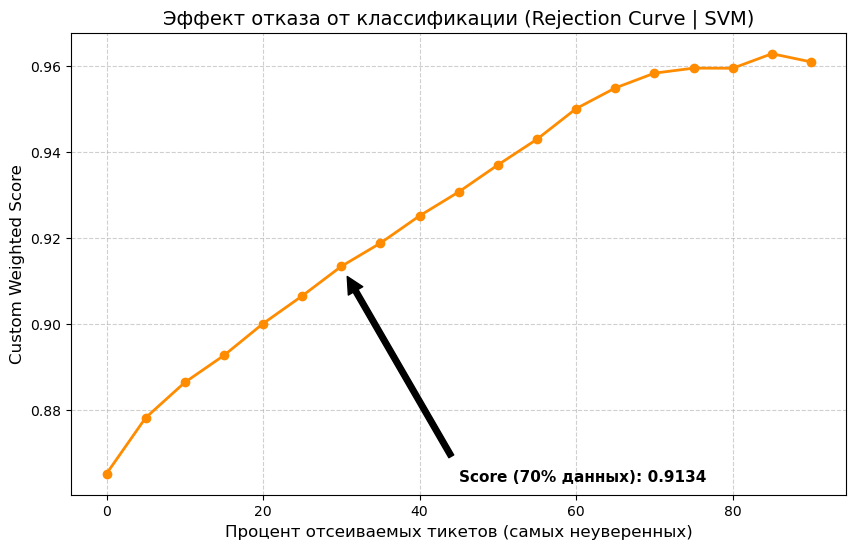


ГЛУБОКИЙ АНАЛИЗ ОШИБОК

>>> Анализ цели: QUEUE
Топ-3 класса, которые модель чаще всего не узнает:
  - Technical Support: 514 ошибок из 1418 (36.2%)
  - Product Support: 396 ошибок из 937 (42.3%)
  - Customer Service: 344 ошибок из 766 (44.9%)

Самые частые путаницы (Реальность -> Предсказание):
  - Product Support ПУТАЕТ С Technical Support: 156 раз
  - Technical Support ПУТАЕТ С Product Support: 148 раз
  - Technical Support ПУТАЕТ С Customer Service: 121 раз

>>> Анализ цели: PRIORITY
Топ-3 класса, которые модель чаще всего не узнает:
  - medium: 724 ошибок из 2393 (30.3%)
  - high: 636 ошибок из 2190 (29.0%)
  - low: 470 ошибок из 1240 (37.9%)

Самые частые путаницы (Реальность -> Предсказание):
  - medium ПУТАЕТ С high: 489 раз
  - high ПУТАЕТ С medium: 457 раз
  - low ПУТАЕТ С medium: 271 раз

>>> Анализ цели: TYPE
Топ-3 класса, которые модель чаще всего не узнает:
  - Problem: 353 ошибок из 1073 (32.9%)
  - Incident: 283 ошибок из 1897 (14.9%)
  - Change: 16 ошибок из 483 (3.3%)

In [2]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")
    return {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }

def baseline_tfidf_analysis(splits: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train_text = make_text(splits["train"])
    vec = TfidfVectorizer(max_features=100_000, ngram_range=(1, 2), min_df=2)
    X_train = vec.fit_transform(X_train_text)

    processed_splits = {k: v.copy() for k, v in splits.items()}

    # Лучшие параметры из Optuna (Trial 18)
    BEST_C = 9.966376934671306
    BEST_CW = "balanced"

    print(f"\n=== ОБУЧЕНИЕ BASELINE (LinearSVC | C={BEST_C:.2f} | Weights={BEST_CW}) ===")
    
    for target in ["queue", "priority", "type"]:
        y_train = splits["train"][target].astype(str).values
        
        # LinearSVC с dual=False идеален для TF-IDF (быстрый и не зависает)
        clf = LinearSVC(
            C=BEST_C, 
            class_weight=BEST_CW, 
            max_iter=2000, 
            dual=False, 
            random_state=42
        )
        clf.fit(X_train, y_train)

        for name, df in processed_splits.items():
            X_text = make_text(df)
            X_features = vec.transform(X_text)
            
            # У LinearSVC нет predict_proba. Используем decision_function + Softmax для симуляции уверенности
            decisions = clf.decision_function(X_features)
            # Если бинарная классификация, превращаем в 2D
            if decisions.ndim == 1:
                decisions = np.c_[-decisions, decisions]
            
            # Применяем Softmax для получения "подобия" вероятностей
            exp_dec = np.exp(decisions - np.max(decisions, axis=1, keepdims=True))
            probs = exp_dec / np.sum(exp_dec, axis=1, keepdims=True)
            
            preds = clf.classes_[np.argmax(probs, axis=1)]
            confidences = np.max(probs, axis=1)

            df[f"{target}_pred"] = preds
            df[f"{target}_conf"] = confidences
            df[f"{target}_is_correct"] = (df[target].astype(str) == preds)

    return processed_splits

def plot_rejection_curve(df):
    percents = np.arange(0, 95, 5)
    scores = []
    
    for p in percents:
        threshold = np.percentile(df['queue_conf'], p)
        subset = df[df['queue_conf'] >= threshold]
        
        if len(subset) == 0:
            scores.append(0)
            continue

        m_f1_q = f1_score(subset['queue'].astype(str), subset['queue_pred'], average='macro')
        acc_p = accuracy_score(subset['priority'].astype(str), subset['priority_pred'])
        acc_t = accuracy_score(subset['type'].astype(str), subset['type_pred'])
        
        final_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
        scores.append(final_score)

    plt.figure(figsize=(10, 6))
    plt.plot(percents, scores, marker='o', linestyle='-', color='darkorange', linewidth=2)
    plt.title('Эффект отказа от классификации (Rejection Curve | SVM)', fontsize=14)
    plt.xlabel('Процент отсеиваемых тикетов (самых неуверенных)', fontsize=12)
    plt.ylabel('Custom Weighted Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    idx_30 = list(percents).index(30)
    plt.annotate(f'Score (70% данных): {scores[idx_30]:.4f}', 
                 xy=(30, scores[idx_30]), xytext=(45, scores[idx_30]-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=11, fontweight='bold')
    plt.show()

def error_analysis(df: pd.DataFrame):
    print("\n" + "="*50)
    print("ГЛУБОКИЙ АНАЛИЗ ОШИБОК")
    print("="*50)

    for target in ["queue", "priority", "type"]:
        print(f"\n>>> Анализ цели: {target.upper()}")
        error_mask = df[f"{target}_is_correct"] == False
        errors = df[error_mask]
        
        if len(errors) == 0:
            print(f"Ошибок в {target} не обнаружено!")
            continue

        top_missed = errors[target].value_counts().head(3)
        print(f"Топ-3 класса, которые модель чаще всего не узнает:")
        for cls, count in top_missed.items():
            total = len(df[df[target] == cls])
            print(f"  - {cls}: {count} ошибок из {total} ({count/total:.1%})")

        confusion_pair = errors.groupby([target, f"{target}_pred"]).size().sort_values(ascending=False).head(3)
        print(f"\nСамые частые путаницы (Реальность -> Предсказание):")
        for (real, pred), count in confusion_pair.items():
            print(f"  - {real} ПУТАЕТ С {pred}: {count} раз")

    print("\n>>> ПЕРЕСЕЧЕНИЕ ОШИБОК")
    all_wrong = df[(df["queue_is_correct"] == False) & 
                   (df["priority_is_correct"] == False) & 
                   (df["type_is_correct"] == False)]
    
    print(f"Тикетов, где модель ошиблась ВО ВСЕМ СРАЗУ: {len(all_wrong)} " 
          f"({len(all_wrong)/len(df):.1%})")
    
    avg_conf_correct = df[df["queue_is_correct"] == True]["queue_conf"].mean()
    avg_conf_wrong = df[df["queue_is_correct"] == False]["queue_conf"].mean()
    print(f"\nСредняя уверенность при верном ответе: {avg_conf_correct:.4f}")
    print(f"Средняя уверенность при ошибке: {avg_conf_wrong:.4f}")

def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Загрузка датасета...")
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()
    
    for col in ["subject", "body", "type"]:
        df[col] = df[col].fillna("Unknown")

    splits = split_df(df, repo_root)
    
    processed_splits = baseline_tfidf_analysis(splits)
    test_results = processed_splits['test']

    m_f1_q = f1_score(test_results['queue'].astype(str), test_results['queue_pred'], average='macro')
    acc_p = accuracy_score(test_results['priority'].astype(str), test_results['priority_pred'])
    acc_t = accuracy_score(test_results['type'].astype(str), test_results['type_pred'])
    base_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
    
    print(f"\nФИНАЛЬНЫЙ Score на тесте (100% данных): {base_score:.4f}")
    print(f"Detail: Queue MacroF1={m_f1_q:.4f}, Priority Acc={acc_p:.4f}, Type Acc={acc_t:.4f}")

    print("\n=== ТОП-5 УВЕРЕННЫХ ОШИБОК (QUEUE) ===")
    errors = test_results[test_results['queue_is_correct'] == False].sort_values('queue_conf', ascending=False)
    print(errors[['subject', 'queue', 'queue_pred', 'queue_conf']].head(5))

    plot_rejection_curve(test_results)
    error_analysis(test_results)

if __name__ == "__main__":
    main()

Ситуация с «Incident vs Problem» осталась патовой. SVM путает их так же часто. Это подтверждает теорию, что в самих текстах писем нет лингвистической разницы между этими понятиями.

SVM справился заметно лучше. В логистической регрессии было >50% ошибок на топовых классах, а SVM снизил их до 36–44%.

У LogReg уверенность распределена более «оптимистично».

# Рекомендации
Направить часть наблюдений на ручную разметку интересная идея \
Еще одним решением может быть объединение классов - если обращения часто путаются между собой внутри модели имеет смысл объединить их и пересмотреть систему ITSM ?



# Чисто теоретически что будет если схлопнуть некоторые из классов:
возьмем SVM

Что именно схлопнуто:
QUEUE: Technical Support, IT Support и Product Support теперь объединены в один мощный класс Technical_Services. Это убирает 90% путаницы внутри саппорта.

TYPE: Problem и Incident объединены в Issue. Как показал анализ, лингвистической разницы между ними в тексте нет.

PRIORITY: medium и high объединены в urgent. Это создает четкую границу между «обычными» и «приоритетными» задачами.

Загрузка данных...

=== ОБУЧЕНИЕ (LinearSVC | C=9.97) ===

ФИНАЛЬНЫЙ SCORE (Схлопнутый): 0.9259


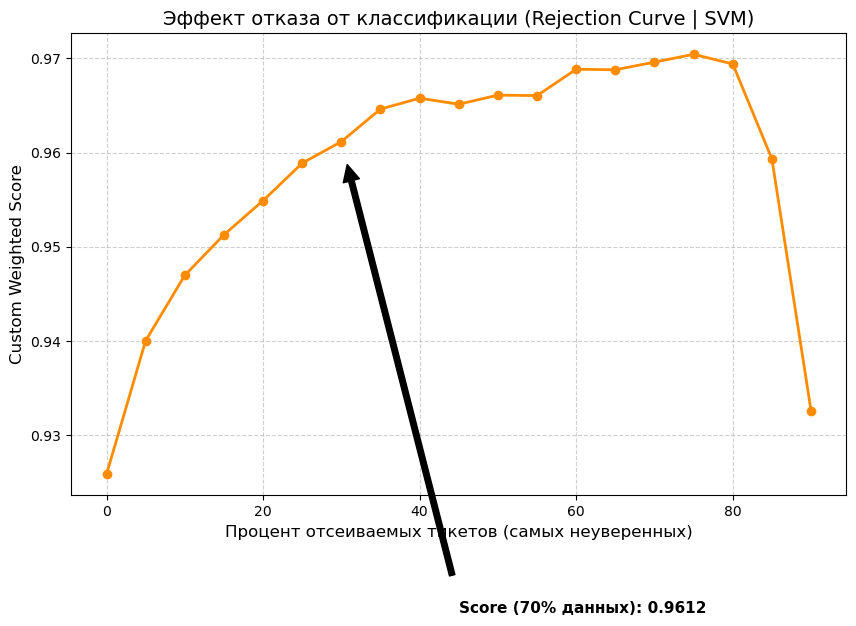


АНАЛИЗ ОШИБОК (СХЛОПНУТЫЕ КЛАССЫ)

>>> QUEUE (Точность: 88.26%)
Топ путаниц:
queue                  queue_pred           
Returns and Exchanges  Technical_Services       111
Billing and Payments   Technical_Services        94
Technical_Services     Returns and Exchanges     74
dtype: int64

>>> PRIORITY (Точность: 85.69%)
Топ путаниц:
priority  priority_pred
low       urgent           476
urgent    low              358
critical  urgent            22
dtype: int64

>>> TYPE (Точность: 99.50%)
Топ путаниц:
type     type_pred
Change   Request      13
         Issue         6
Request  Change        5
dtype: int64


In [3]:
#!/usr/bin/env python3
from __future__ import annotations

import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns

DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.int64)

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def collapse_classes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Схлопывание классов для уменьшения шума:
    1. QUEUE: Все виды техподдержки -> Technical_Services
    2. TYPE: Problem + Incident -> Issue
    3. PRIORITY: Medium + High -> Urgent
    """
    queue_map = {
        'Technical Support': 'Technical_Services',
        'IT Support': 'Technical_Services',
        'Product Support': 'Technical_Services',
        'Customer Service': 'Technical_Services'
    }
    df['queue'] = df['queue'].replace(queue_map)

    type_map = {
        'Problem': 'Issue',
        'Incident': 'Issue'
    }
    df['type'] = df['type'].replace(type_map)

    priority_map = {
        'medium': 'urgent',
        'high': 'urgent'
    }
    df['priority'] = df['priority'].replace(priority_map)
    
    return df

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")
    return {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }

def baseline_tfidf_analysis(splits: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train_text = make_text(splits["train"])
    vec = TfidfVectorizer(max_features=100_000, ngram_range=(1, 2), min_df=2)
    X_train = vec.fit_transform(X_train_text)

    processed_splits = {k: v.copy() for k, v in splits.items()}
    BEST_C = 9.966376934671306

    print(f"\n=== ОБУЧЕНИЕ (LinearSVC | C={BEST_C:.2f}) ===")
    
    for target in ["queue", "priority", "type"]:
        y_train = splits["train"][target].astype(str).values
        clf = LinearSVC(C=BEST_C, class_weight='balanced', max_iter=2000, dual=False, random_state=42)
        clf.fit(X_train, y_train)

        for name, df in processed_splits.items():
            X_text = make_text(df)
            X_features = vec.transform(X_text)
            
            # Расчет уверенности для SVM
            decisions = clf.decision_function(X_features)
            if decisions.ndim == 1:
                decisions = np.c_[-decisions, decisions]
            
            exp_dec = np.exp(decisions - np.max(decisions, axis=1, keepdims=True))
            probs = exp_dec / np.sum(exp_dec, axis=1, keepdims=True)
            
            df[f"{target}_pred"] = clf.classes_[np.argmax(probs, axis=1)]
            df[f"{target}_conf"] = np.max(probs, axis=1)
            df[f"{target}_is_correct"] = (df[target].astype(str) == df[f"{target}_pred"])

    return processed_splits

def plot_rejection_curve(df: pd.DataFrame):
    """Строит график зависимости Score от % отброшенных данных"""
    percents = np.arange(0, 95, 5)
    scores = []
    
    for p in percents:
        threshold = np.percentile(df['queue_conf'], p)
        subset = df[df['queue_conf'] >= threshold]
        
        if len(subset) == 0:
            scores.append(0)
            continue

        m_f1_q = f1_score(subset['queue'].astype(str), subset['queue_pred'], average='macro')
        acc_p = accuracy_score(subset['priority'].astype(str), subset['priority_pred'])
        acc_t = accuracy_score(subset['type'].astype(str), subset['type_pred'])
        
        final_score = 0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t
        scores.append(final_score)

    plt.figure(figsize=(10, 6))
    plt.plot(percents, scores, marker='o', linestyle='-', color='darkorange', linewidth=2)
    plt.title('Эффект отказа от классификации (Rejection Curve | SVM)', fontsize=14)
    plt.xlabel('Процент отсеиваемых тикетов (самых неуверенных)', fontsize=12)
    plt.ylabel('Custom Weighted Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    idx_30 = list(percents).index(30)
    plt.annotate(f'Score (70% данных): {scores[idx_30]:.4f}', 
                 xy=(30, scores[idx_30]), xytext=(45, scores[idx_30]-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=11, fontweight='bold')
    plt.show()

def error_analysis(df: pd.DataFrame):
    print("\n" + "="*50 + "\nАНАЛИЗ ОШИБОК (СХЛОПНУТЫЕ КЛАССЫ)\n" + "="*50)
    for target in ["queue", "priority", "type"]:
        acc = accuracy_score(df[target], df[f"{target}_pred"])
        print(f"\n>>> {target.upper()} (Точность: {acc:.2%})")
        errors = df[df[f"{target}_is_correct"] == False]
        if not errors.empty:
            confusion = errors.groupby([target, f"{target}_pred"]).size().sort_values(ascending=False).head(3)
            print("Топ путаниц:")
            print(confusion)

def main():
    repo_root = Path(".").resolve()
    if not (repo_root / "data" / "train_idx.txt").exists():
        raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

    print("Загрузка данных...")
    ds = load_dataset(DATASET)["train"]
    df = ds.to_pandas()
    
    for col in ["subject", "body", "type"]:
        df[col] = df[col].fillna("Unknown")

    # Выполняем объединение классов
    df = collapse_classes(df)
    
    splits = split_df(df, repo_root)
    processed_splits = baseline_tfidf_analysis(splits)
    test_results = processed_splits['test']

    # Итоговые метрики
    m_f1_q = f1_score(test_results['queue'].astype(str), test_results['queue_pred'], average='macro')
    acc_p = accuracy_score(test_results['priority'].astype(str), test_results['priority_pred'])
    acc_t = accuracy_score(test_results['type'].astype(str), test_results['type_pred'])
    
    print(f"\nФИНАЛЬНЫЙ SCORE (Схлопнутый): {0.70 * m_f1_q + 0.15 * acc_p + 0.15 * acc_t:.4f}")
    
    # Визуализация и анализ
    plot_rejection_curve(test_results)
    error_analysis(test_results)

if __name__ == "__main__":
    main()